In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/appendix"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 付録 A: 線形代数 (Appendix A: Linear Algebra)

『深層学習：基礎と概念 (Christopher M. Bishop & Hugh Bishop 著, Springer 2024)』**付録 A「線形代数」**の数理的基礎、全恒等式のステップ・バイ・ステップの厳密導出、および Python / NumPy による数値検証と幾何学的可視化を徹底解説します。

深層学習における多変量正規分布、主成分分析（PCA）、自己符号化器、正規化フロー、拡散モデル（確率流ODE/SDE）など、あらゆる先端トピックの根底にある線形代数の公式と定理を体系的に整理します。

---

## 本付録のアジェンダと網羅する小節

1. **A.1 行列の恒等式 (Matrix Identities)**
   - 転置行列と逆行列の基本性質 (式 A.1 〜 A.4)
   - 低ランク更新恒等式 (式 A.5) とその計算量削減メリット
   - 押し通し恒等式 (Push-through identity, 式 A.6)
   - ウッドベリーの公式 (Woodbury Identity, 式 A.7) の厳密展開証明
   - 線形独立性 (Linear Independence) と行列の階数 (Rank)

2. **A.2 トレースと行列式 (Traces and Determinants)**
   - トレースの定義と巡回不変性 (Cyclic property, 式 A.8 〜 A.9)
   - 行列式の置換展開定義 (Leibniz formula, 式 A.10 〜 A.11)
   - 積と逆行列の行列式公式 (式 A.12 〜 A.13)
   - Weinstein-Aronszajn の恒等式 (式 A.14)
   - ランク1更新の行列式補題 (Matrix determinant lemma, 式 A.15)

3. **A.3 行列の微分 (Matrix Derivatives)**
   - スカラー・ベクトル・行列による微分の定義 (式 A.16 〜 A.18)
   - 1次形式（線形形式）の勾配公式 (式 A.19)
   - 積の微分則と逆行列の微分導出 (式 A.20 〜 A.21)
   - 対数行列式のスカラー微分 (式 A.22)
   - トレースの行列微分恒等式 (式 A.23 〜 A.27)
   - 対数行列式の行列微分公式 (式 A.28)

4. **A.4 固有ベクトルと固有値 (Eigenvectors)**
   - 固有値方程式と特性方程式 (式 A.29 〜 A.30)
   - 実対称行列の固有値が実数であることの厳密証明 (式 A.31 〜 A.32)
   - 固有ベクトルの直交性証明 (式 A.33 〜 A.36)
   - 直交行列 $U$ と座標の剛体回転（ノルム・内積の不変性） (式 A.37 〜 A.41)
   - 対角化とスペクトル分解 (式 A.42 〜 A.44)
   - ダイアド（外積）展開公式 (式 A.45 〜 A.46)
   - 行列式・トレースと固有値の関係 (式 A.47 〜 A.48)
   - 正定値性・半正定値性と教科書の重要反例 (式 A.49)
   - 条件数 (Condition number, 式 A.50)


In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "appendix" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style, save_plot
from common.linear_algebra import (
    verify_matrix_transpose_product,
    verify_matrix_inverse_product,
    low_rank_update_identity,
    push_through_identity,
    woodbury_inversion,
    verify_trace_cyclic,
    weinstein_aronszajn_determinant,
    rank1_determinant_lemma,
    verify_matrix_inverse_derivative,
    verify_log_det_scalar_derivative,
    verify_matrix_derivatives_identities,
    SymmetricMatrixSpectralAnalysis,
    generate_all_appendix_a_figures,
)

setup_style()
print("付録 A: 線形代数 モジュール準備完了")


付録 A: 線形代数 モジュール準備完了


---

### A.1 行列の恒等式 (Matrix Identities)

行列 $A$ の $i$ 行 $j$ 列の要素を $A_{ij}$ と表します。$N \times N$ の単位行列を $I_N$（文脈上自明な場合は $I$）と表記します。

#### 1. 転置行列の性質 (Transpose Properties)
転置行列 $A^T$ の要素は $(A^T)_{ij} = A_{ji}$ と定義されます。行列積 $AB$ の転置について、インデックス展開を行うと：
$$
((AB)^T)_{ij} = (AB)_{ji} = \sum_k A_{jk} B_{ki} = \sum_k (B^T)_{ik} (A^T)_{kj} = (B^T A^T)_{ij}
$$
したがって、以下の積の転置公式が成立します：
$$
(AB)^T = B^T A^T \tag{A.1}
$$

#### 2. 逆行列の性質 (Inverse Properties)
正方行列 $A$ の逆行列 $A^{-1}$ は、次式を満たす一意の行列です：
$$
A A^{-1} = A^{-1} A = I \tag{A.2}
$$
$AB$ に $B^{-1} A^{-1}$ を右から乗じると：
$$
(AB)(B^{-1} A^{-1}) = A (B B^{-1}) A^{-1} = A I A^{-1} = A A^{-1} = I
$$
したがって、積の逆行列公式が得られます：
$$
(AB)^{-1} = B^{-1} A^{-1} \tag{A.3}
$$
また、式(A.2)の両辺の転置をとると、式(A.1)より $(A^{-1})^T A^T = I^T = I$ となるため：
$$
(A^T)^{-1} = (A^{-1})^T \tag{A.4}
$$
が成り立ちます。

#### 3. 低ランク更新の逆行列恒等式 (Low-Rank Update Identity)
カルマンフィルタやガウス過程の導出で頻出する恒等式が次式です：
$$
(P^{-1} + B^T R^{-1} B)^{-1} B^T R^{-1} = P B^T (B P B^T + R)^{-1} \tag{A.5}
$$
ここで、$P$ は $N \times N$、$R$ は $M \times M$、$B$ は $M \times N$ 行列です。

**【式(A.5)のステップ・バイ・ステップ証明】**
両辺に右から $(B P B^T + R)$ を乗じ、両者が一致することを示します。
- 右辺 $\times (B P B^T + R)$:
  $$
  P B^T (B P B^T + R)^{-1} (B P B^T + R) = P B^T
  $$
- 左辺 $\times (B P B^T + R)$:
  $$
  (P^{-1} + B^T R^{-1} B)^{-1} B^T R^{-1} (B P B^T + R)
  $$
  括弧を展開すると：
  $$
  = (P^{-1} + B^T R^{-1} B)^{-1} [ B^T R^{-1} B P B^T + B^T ]
  $$
  共通の $B^T$ と $P B^T$ を整理するため、$B^T R^{-1} B P B^T + B^T = (B^T R^{-1} B + P^{-1}) P B^T$ と変形できます：
  $$
  = (P^{-1} + B^T R^{-1} B)^{-1} (P^{-1} + B^T R^{-1} B) P B^T = I \cdot P B^T = P B^T
  $$
両辺に同一の可逆行列を右乗して一致するため、式(A.5)が証明されました。
特に $M \ll N$（例: 特徴量次元 $N=1000$、観測次元 $M=2$）の場合、左辺の逆行列計算は $\mathcal{O}(N^3)$ ですが、右辺の括弧内の逆行列は $M \times M$ であるため計算量はわずか $\mathcal{O}(M^3)$ となり、圧倒的な高速化が実現されます。

#### 4. 押し通し恒等式 (Push-through Identity)
式(A.5)の特殊ケースとして、$P = I_N, R = I_M$ と置くと：
$$
(I_N + AB)^{-1} A = A (I_M + BA)^{-1} \tag{A.6}
$$
が得られます。

#### 5. ウッドベリーの公式 (Woodbury Matrix Identity)
機械学習全般で最も広く用いられる逆行列公式が**ウッドベリーの公式**です：
$$
(A + B D^{-1} C)^{-1} = A^{-1} - A^{-1} B (D + C A^{-1} B)^{-1} C A^{-1} \tag{A.7}
$$
ここで、$A$ は $N \times N$、$B$ は $N \times M$、$D$ は $M \times M$、$C$ は $M \times N$ です。
特に $A$ が対角行列など逆行列が容易に求まる構造であり、$M \ll N$ である場合、左辺の $\mathcal{O}(N^3)$ の直接逆行列計算を、右辺の $M \times M$ 逆行列計算 $\mathcal{O}(M^3 + N M^2)$ に帰着できます。


In [3]:
# === A.1 行列恒等式の数値検証と計算量ベンチマーク ===
np.random.seed(42)

# 1. 転置・逆行列の積の検証 (式 A.1, A.3, A.4)
A_mat = np.random.randn(5, 5)
B_mat = np.random.randn(5, 5)
assert verify_matrix_transpose_product(A_mat, B_mat), "(AB)^T = B^T A^T 検証失敗"
assert verify_matrix_inverse_product(A_mat, B_mat), "(AB)^-1 = B^-1 A^-1 検証失敗"
print("[OK] 式 (A.1) 〜 (A.4) 転置・逆行列の恒等式が成立")

# 2. 低ランク更新恒等式の検証 (式 A.5)
N, M = 8, 3
P = np.random.randn(N, N); P = P @ P.T + np.eye(N)
R = np.random.randn(M, M); R = R @ R.T + np.eye(M)
B = np.random.randn(M, N)
res_lowrank = low_rank_update_identity(P, B, R)
print(f"[OK] 式 (A.5) 低ランク更新恒等式: 最大差分 = {res_lowrank['max_diff']:.2e}")
assert res_lowrank['is_equivalent']

# 3. 押し通し恒等式 (式 A.6)
res_push = push_through_identity(A=np.random.randn(5, 2), B=np.random.randn(2, 5))
print(f"[OK] 式 (A.6) 押し通し恒等式: 最大差分 = {res_push['max_diff']:.2e}")
assert res_push['is_equivalent']

# 4. ウッドベリーの公式 (式 A.7)
D = np.random.randn(M, M); D = D @ D.T + np.eye(M)
C = np.random.randn(M, N)
res_woodbury = woodbury_inversion(P, B.T, D, C)
print(f"[OK] 式 (A.7) ウッドベリーの公式: 最大差分 = {res_woodbury['max_diff']:.2e}")
assert res_woodbury['is_equivalent']

# 5. Woodbury 高速化ベンチマーク図版 (Figure A.4) の生成
fig_a4 = generate_all_appendix_a_figures()
print("\n[図版保存完了] appendix/result/figA_4_woodbury_speedup.png")


[OK] 式 (A.1) 〜 (A.4) 転置・逆行列の恒等式が成立
[OK] 式 (A.5) 低ランク更新恒等式: 最大差分 = 1.28e-15
[OK] 式 (A.6) 押し通し恒等式: 最大差分 = 1.08e-12
[OK] 式 (A.7) ウッドベリーの公式: 最大差分 = 4.44e-16


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_1_orthogonal_rotation.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figA_1_orthogonal_rotation.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_2_spectral_decomposition_ellipse.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figA_2_spectral_decomposition_ellipse.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_3_quadratic_forms.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figA_3_quadratic_forms.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_4_woodbury_speedup.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figA_4_woodbury_speedup.png

[図版保存完了] appendix/result/figA_4_woodbury_speedup.png


---

### A.2 トレースと行列式 (Traces and Determinants)

正方行列において定義されるトレース（跡）と行列式（行列の体積スケーリング因子）の重要恒等式を導出します。

#### 1. トレースの巡回不変性 (Cyclic Property of Trace)
$N \times N$ 行列 $A$ のトレース $\text{Tr}(A)$ は主対角成分の和です：
$$
\text{Tr}(A) = \sum_{i=1}^N A_{ii}
$$
2つの行列の積 $AB$ について展開すると：
$$
\text{Tr}(AB) = \sum_{i=1}^N (AB)_{ii} = \sum_{i=1}^N \sum_{j=1}^M A_{ij} B_{ji} = \sum_{j=1}^M \sum_{i=1}^N B_{ji} A_{ij} = \sum_{j=1}^M (BA)_{jj} = \text{Tr}(BA) \tag{A.8}
$$
これを 3 つ以上の行列の積に拡張すると、巡回置換（cyclic permutation）に対してトレースが不変であることが直ちに導かれます：
$$
\text{Tr}(ABC) = \text{Tr}((AB)C) = \text{Tr}(C(AB)) = \text{Tr}(CAB) = \text{Tr}(BCA) \tag{A.9}
$$
※注意: 巡回順序を保持しない置換（例: $\text{Tr}(ABC)$ と $\text{Tr}(BAC)$）は一般には等しくありません。

#### 2. 行列式の定義と性質 (Determinants)
$N \times N$ 行列 $A$ の行列式 $|A|$ はライプニッツの明示公式によって定義されます：
$$
|A| = \sum_{i_1, \dots, i_N} (\pm 1) A_{1 i_1} A_{2 i_2} \cdots A_{N i_N} \tag{A.10}
$$
ここで和は各行・各列からちょうど 1 つずつの要素を選ぶ全置換にわたり、偶置換なら $+1$、奇置換なら $-1$ の符号が付きます。
- 単位行列: $|I| = 1$
- 対角行列: 主対角成分の積 $|D| = \prod_i D_{ii}$
- $2 \times 2$ 行列:
  $$
  |A| = \begin{vmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{vmatrix} = a_{11} a_{22} - a_{12} a_{21} \tag{A.11}
  $$
- 行列積の行列式:
  $$
  |AB| = |A| |B| \tag{A.12}
  $$
- 逆行列の行列式:
  式(A.2) $A A^{-1} = I$ に式(A.12)を適用すると $|A| |A^{-1}| = |I| = 1$ となるため：
  $$
  |A^{-1}| = \frac{1}{|A|} \tag{A.13}
  $$

#### 3. Weinstein-Aronszajn 恒等式 (Sylvester's Determinant Theorem)
$A, B$ が $N \times M$ 行列であるとき、次の驚くべき行列式恒等式が成り立ちます：
$$
|I_N + A B^T| = |I_M + A^T B| \tag{A.14}
$$
**【証明の要点】**
ブロック行列 $\begin{pmatrix} I_N & -A \\ B^T & I_M \end{pmatrix}$ のシューア補元（Schur complement）を 2 通りの順序で計算することで、$|I_N| |I_M + B^T I_N^{-1} A| = |I_M| |I_N + A I_M^{-1} B^T|$ から直ちに導かれます。

#### 4. ランク1更新の行列式補題 (Matrix Determinant Lemma)
式(A.14)の特殊ケースとして、$M=1$ とし、$A = \mathbf{a}, B = \mathbf{b}$ を $N$ 次元列ベクトルとすると、右辺はスカラーの行列式（その値自身）となるため：
$$
|I_N + \mathbf{a} \mathbf{b}^T| = 1 + \mathbf{a}^T \mathbf{b} \tag{A.15}
$$
が得られます。この公式は、ランク1更新による多変量正規分布の正規化定数計算やシャーマン・モリソン公式と対をなす重要な補題です。


In [4]:
# === A.2 トレースと行列式の数値検証 ===
np.random.seed(123)

# 1. トレースの巡回不変性 (式 A.8, A.9)
A3 = np.random.randn(4, 5)
B3 = np.random.randn(5, 6)
C3 = np.random.randn(6, 4)
res_cyclic = verify_trace_cyclic([A3, B3, C3])
print(f"[OK] 式 (A.9) Tr(ABC) = Tr(CAB) = Tr(BCA): 最大差分 = {res_cyclic['max_diff']:.2e}")
assert res_cyclic['is_cyclic_invariant']

# 2. 積と逆行列の行列式 (式 A.12, A.13)
M_sq = np.random.randn(4, 4)
N_sq = np.random.randn(4, 4)
det_MN = np.linalg.det(M_sq @ N_sq)
det_prod = np.linalg.det(M_sq) * np.linalg.det(N_sq)
print(f"[OK] 式 (A.12) |MN| = |M||N|: 差分 = {abs(det_MN - det_prod):.2e}")
assert np.isclose(det_MN, det_prod)

det_inv = np.linalg.det(np.linalg.inv(M_sq))
print(f"[OK] 式 (A.13) |M^-1| = 1/|M|: 差分 = {abs(det_inv - 1.0 / np.linalg.det(M_sq)):.2e}")
assert np.isclose(det_inv, 1.0 / np.linalg.det(M_sq))

# 3. Weinstein-Aronszajn 恒等式 (式 A.14)
N_dim, M_dim = 10, 2
A_rect = np.random.randn(N_dim, M_dim)
B_rect = np.random.randn(N_dim, M_dim)
res_wa = weinstein_aronszajn_determinant(A_rect, B_rect)
print(f"[OK] 式 (A.14) |I_10 + AB^T| = |I_2 + A^TB|: |LHS|={res_wa['det_lhs']:.4f}, |RHS|={res_wa['det_rhs']:.4f}, 差分={res_wa['diff']:.2e}")
assert res_wa['is_equivalent']

# 4. ランク1行列式補題 (式 A.15)
a_vec = np.random.randn(10)
b_vec = np.random.randn(10)
res_rank1 = rank1_determinant_lemma(a_vec, b_vec)
print(f"[OK] 式 (A.15) |I_10 + ab^T| = 1 + a^Tb: |LHS|={res_rank1['det_lhs']:.4f}, 1+a^Tb={res_rank1['scalar_rhs']:.4f}, 差分={res_rank1['diff']:.2e}")
assert res_rank1['is_equivalent']


[OK] 式 (A.9) Tr(ABC) = Tr(CAB) = Tr(BCA): 最大差分 = 3.55e-15
[OK] 式 (A.12) |MN| = |M||N|: 差分 = 9.95e-14
[OK] 式 (A.13) |M^-1| = 1/|M|: 差分 = 0.00e+00
[OK] 式 (A.14) |I_10 + AB^T| = |I_2 + A^TB|: |LHS|=-14.7716, |RHS|=-14.7716, 差分=0.00e+00
[OK] 式 (A.15) |I_10 + ab^T| = 1 + a^Tb: |LHS|=-2.3085, 1+a^Tb=-2.3085, 差分=4.44e-16


---

### A.3 行列の微分 (Matrix Derivatives)

深層学習におけるバックプロパゲーション、損失関数最小化、多変量ガウス分布の最尤推定において不可欠な行列微分の公式体系です。

#### 1. 微分の表記法と定義
- スカラー $x$ によるベクトル $\mathbf{a}$ の微分（各成分を微分したベクトル）：
  $$
  \left(\frac{\partial \mathbf{a}}{\partial x}\right)_i = \frac{\partial a_i}{\partial x} \tag{A.16}
  $$
- ベクトル $\mathbf{a}$ によるスカラー $x$ の微分（勾配ベクトル）：
  $$
  \left(\frac{\partial x}{\partial \mathbf{a}}\right)_i = \frac{\partial x}{\partial a_i} \tag{A.17}
  $$
- ベクトル $\mathbf{b}$ によるベクトル $\mathbf{a}$ の微分（ヤコビ行列 Jacobian matrix）：
  $$
  \left(\frac{\partial \mathbf{a}}{\partial \mathbf{b}}\right)_{ij} = \frac{\partial a_i}{\partial b_j} \tag{A.18}
  $$

#### 2. 1次形式（線形形式）の勾配
$\mathbf{x}^T \mathbf{a} = \mathbf{a}^T \mathbf{x} = \sum_j x_j a_j$ です。$x_i$ で偏微分すると：
$$
\frac{\partial}{\partial x_i} \left( \sum_j x_j a_j \right) = a_i \implies \frac{\partial}{\partial \mathbf{x}} (\mathbf{x}^T \mathbf{a}) = \frac{\partial}{\partial \mathbf{x}} (\mathbf{a}^T \mathbf{x}) = \mathbf{a} \tag{A.19}
$$

#### 3. 積の微分則と逆行列の微分
スカラー $x$ に依存する行列積 $AB$ の微分は、通常のライプニッツ則がそのまま成り立ちます（ただし行列の順序は厳密に保持）：
$$
\frac{\partial}{\partial x}(AB) = \frac{\partial A}{\partial x} B + A \frac{\partial B}{\partial x} \tag{A.20}
$$

**【逆行列の微分 式(A.21)のステップ・バイ・ステップ証明】**
恒等式 $A^{-1} A = I$ の両辺をスカラー $x$ で微分します。右辺の $I$ は定数行列なので微分はゼロです：
$$
\frac{\partial}{\partial x} (A^{-1} A) = \frac{\partial A^{-1}}{\partial x} A + A^{-1} \frac{\partial A}{\partial x} = 0
$$
第2項を移項すると：
$$
\frac{\partial A^{-1}}{\partial x} A = - A^{-1} \frac{\partial A}{\partial x}
$$
両辺に右から $A^{-1}$ を乗じると、$A A^{-1} = I$ より直ちに次式が得られます：
$$
\frac{\partial A^{-1}}{\partial x} = - A^{-1} \frac{\partial A}{\partial x} A^{-1} \tag{A.21}
$$

#### 4. 対数行列式のスカラー微分
正方行列 $A(x)$ の対数行列式 $\ln |A|$ の微分は次式で与えられます：
$$
\frac{\partial}{\partial x} \ln |A| = \text{Tr}\left( A^{-1} \frac{\partial A}{\partial x} \right) \tag{A.22}
$$
後述のスペクトル分解により証明されます。

#### 5. トレースと行列自体の微分公式
行列 $A$ の各成分 $A_{ij}$ によるスカラー関数の偏微分を $( \frac{\partial f}{\partial A} )_{ij} = \frac{\partial f}{\partial A_{ij}}$ と定義します。
$\text{Tr}(AB) = \sum_{k,l} A_{kl} B_{lk}$ より：
$$
\frac{\partial}{\partial A_{ij}} \text{Tr}(AB) = B_{ji} \tag{A.23}
$$
これを行列記法でまとめると：
$$
\frac{\partial}{\partial A} \text{Tr}(AB) = B^T \tag{A.24}
$$
この結果から、以下の極めて重要な性質群が導かれます：
$$
\frac{\partial}{\partial A} \text{Tr}(A^T B) = B \tag{A.25}
$$
$$
\frac{\partial}{\partial A} \text{Tr}(A) = I \tag{A.26}
$$
$$
\frac{\partial}{\partial A} \text{Tr}(A B A^T) = A (B + B^T) \tag{A.27}
$$
特に $B$ が対称行列 ($B=B^T$) の場合、$\frac{\partial}{\partial A}\text{Tr}(ABA^T) = 2AB$ となります。

#### 6. 対数行列式の行列微分
式(A.22)と(A.24)を組み合わせると、対数行列式の行列自体による勾配が得られます：
$$
\frac{\partial}{\partial A} \ln |A| = (A^{-1})^T \tag{A.28}
$$
特に $A$ が対称行列（共分散行列など）の場合、$A^{-1}$ も対称であるため、単に $A^{-1}$ と一致します。


In [5]:
# === A.3 行列微分の数値有限差分との完全一致検証 ===
np.random.seed(42)

# 1. 逆行列の微分 (式 A.21)
def A_param(x):
    return np.array([
        [np.cos(x) + 2.0, x, 0.5],
        [x, np.sin(x) + 2.0, -0.3],
        [0.5, -0.3, 1.5 + x**2]
    ])
def dA_param(x):
    return np.array([
        [-np.sin(x), 1.0, 0.0],
        [1.0, np.cos(x), 0.0],
        [0.0, 0.0, 2.0 * x]
    ])

res_inv_deriv = verify_matrix_inverse_derivative(A_param, dA_param, x0=0.7)
print(f"[OK] 式 (A.21) d(A^-1)/dx = -A^-1 (dA/dx) A^-1: 数値微分との差分 = {res_inv_deriv['max_diff']:.2e}")
assert res_inv_deriv['is_close']

# 2. 対数行列式のスカラー微分 (式 A.22)
res_logdet_scalar = verify_log_det_scalar_derivative(A_param, dA_param, x0=0.7)
print(f"[OK] 式 (A.22) d/dx ln|A| = Tr(A^-1 dA/dx): 数値微分との差分 = {res_logdet_scalar['diff']:.2e}")
assert res_logdet_scalar['is_close']

# 3. 行列微分の諸公式 (式 A.24 〜 A.28)
A_eval = np.array([[2.5, 0.4, 0.1], [0.3, 1.8, -0.2], [-0.1, 0.5, 3.0]])
B_eval = np.array([[1.0, 0.2, -0.3], [0.2, 2.0, 0.1], [-0.3, 0.1, 1.5]])
res_mat_derivs = verify_matrix_derivatives_identities(A_eval, B_eval)

print(f"[OK] 式 (A.24) d/dA Tr(AB) = B^T: 差分 = {res_mat_derivs['diff_TrAB']:.2e}")
print(f"[OK] 式 (A.25) d/dA Tr(A^T B) = B: 差分 = {res_mat_derivs['diff_TrATB']:.2e}")
print(f"[OK] 式 (A.26) d/dA Tr(A) = I: 差分 = {res_mat_derivs['diff_TrA']:.2e}")
print(f"[OK] 式 (A.27) d/dA Tr(A B A^T) = A(B + B^T): 差分 = {res_mat_derivs['diff_TrABAT']:.2e}")
print(f"[OK] 式 (A.28) d/dA ln|A| = (A^-1)^T: 差分 = {res_mat_derivs['diff_lndet']:.2e}")
assert res_mat_derivs['all_passed']


[OK] 式 (A.21) d(A^-1)/dx = -A^-1 (dA/dx) A^-1: 数値微分との差分 = 3.40e-11
[OK] 式 (A.22) d/dx ln|A| = Tr(A^-1 dA/dx): 数値微分との差分 = 1.31e-11
[OK] 式 (A.24) d/dA Tr(AB) = B^T: 差分 = 6.09e-10
[OK] 式 (A.25) d/dA Tr(A^T B) = B: 差分 = 1.03e-09
[OK] 式 (A.26) d/dA Tr(A) = I: 差分 = 1.40e-10
[OK] 式 (A.27) d/dA Tr(A B A^T) = A(B + B^T): 差分 = 1.91e-09
[OK] 式 (A.28) d/dA ln|A| = (A^-1)^T: 差分 = 1.47e-10


---

### A.4 固有ベクトルと固有値 (Eigenvectors and Spectral Theory)

$M \times M$ の正方行列 $A$ に対して、固有値方程式は次のように定義されます：
$$
A \mathbf{u}_i = \lambda_i \mathbf{u}_i \quad (i = 1, \dots, M) \tag{A.29}
$$
ここで $\mathbf{u}_i$ は固有ベクトル、$\lambda_i$ は対応する固有値です。これは同次連立1次方程式 $(A - \lambda_i I) \mathbf{u}_i = \mathbf{0}$ と等価であり、非自明解 ($\mathbf{u}_i \neq \mathbf{0}$) を持つ必要十分条件は特性方程式です：
$$
|A - \lambda_i I| = 0 \tag{A.30}
$$
これは $\lambda_i$ に関する $M$ 次の多項式であり、重解を含めて必ず $M$ 個の解を持ちます。

#### 1. 実対称行列の固有値が実数であることの証明
共分散行列、カーネル行列、ヘッセ行列など機械学習で現れる行列の多くは実対称行列 ($A^T = A, A^* = A$) です。
複素共役を $*$ で表します。式(A.29)の両辺に左から $(\mathbf{u}_i^*)^T$ を掛けると：
$$
(\mathbf{u}_i^*)^T A \mathbf{u}_i = \lambda_i (\mathbf{u}_i^*)^T \mathbf{u}_i \tag{A.31}
$$
次に、式(A.29)の複素共役を取り、左から $\mathbf{u}_i^T$ を掛けると（$A^* = A$ より）：
$$
\mathbf{u}_i^T A \mathbf{u}_i^* = \lambda_i^* \mathbf{u}_i^T \mathbf{u}_i^* \tag{A.32}
$$
式(A.32)の両辺の転置をとると、スカラーの転置は等しく、$A^T = A$ であるため、左辺は $(\mathbf{u}_i^*)^T A \mathbf{u}_i$ となり式(A.31)の左辺と完全に一致します。したがって右辺も等しく：
$$
\lambda_i (\mathbf{u}_i^*)^T \mathbf{u}_i = \lambda_i^* (\mathbf{u}_i^*)^T \mathbf{u}_i
$$
固有ベクトルは非ゼロベクトルであるため $(\mathbf{u}_i^*)^T \mathbf{u}_i = \|\mathbf{u}_i\|^2 > 0$ であり、両辺を割ることで：
$$
\lambda_i^* = \lambda_i
$$
が得られます。すなわち、**実対称行列の固有値はすべて実数**です。

#### 2. 固有ベクトルの直交性の証明
相異なる固有値 $\lambda_i \neq \lambda_j$ に対応する固有ベクトル $\mathbf{u}_i, \mathbf{u}_j$ の直交性を示します。
$A \mathbf{u}_i = \lambda_i \mathbf{u}_i$ に左から $\mathbf{u}_j^T$ を乗じると：
$$
\mathbf{u}_j^T A \mathbf{u}_i = \lambda_i \mathbf{u}_j^T \mathbf{u}_i \tag{A.34}
$$
インデックスを入れ替えると：
$$
\mathbf{u}_i^T A \mathbf{u}_j = \lambda_j \mathbf{u}_i^T \mathbf{u}_j \tag{A.35}
$$
式(A.35)の転置をとると、$A^T = A$ より左辺は $\mathbf{u}_j^T A \mathbf{u}_i$ となり、式(A.34)と辺々引くと：
$$
(\lambda_i - \lambda_j) \mathbf{u}_i^T \mathbf{u}_j = 0 \tag{A.36}
$$
$\lambda_i \neq \lambda_j$ のとき、直ちに $\mathbf{u}_i^T \mathbf{u}_j = 0$ となり直交性が導かれます。重解の場合もグラム・シュミットの直交化により直交基底を選ぶことができます。
規格化を行えば、正規直交基底が得られます：
$$
\mathbf{u}_i^T \mathbf{u}_j = I_{ij} \tag{A.33}
$$

#### 3. 直交行列 $U$ と剛体回転
固有ベクトルを列ベクトルとして並べた行列 $U = (\mathbf{u}_1, \dots, \mathbf{u}_M)$ は、正規直交性より次を満たします：
$$
U^T U = I \tag{A.37}
$$
このような行列を**直交行列 (Orthogonal matrix)** と呼びます。行ベクトルもまた直交するため $U U^T = I$ であり、$|U| = \pm 1$ です。
直交行列による線形変換 $\tilde{\mathbf{x}} = U \mathbf{x}$ (式 A.39) は：
$$
\tilde{\mathbf{x}}^T \tilde{\mathbf{x}} = \mathbf{x}^T U^T U \mathbf{x} = \mathbf{x}^T \mathbf{x} \tag{A.40}
$$
$$
\tilde{\mathbf{x}}^T \tilde{\mathbf{y}} = \mathbf{x}^T U^T U \mathbf{y} = \mathbf{x}^T \mathbf{y} \tag{A.41}
$$
を満たし、**ベクトルの長さ（ノルム）とベクトル間の角度（内積）を完全に保存する座標系の剛体回転（または鏡映）**を表します。

#### 4. 対角化とスペクトル分解 (Spectral Decomposition)
固有値方程式を行列でまとめると $A U = U \Lambda$ (式 A.38) となり、$U^T$ を左から掛けると対角化されます：
$$
U^T A U = \Lambda \tag{A.42}
$$
両辺に左から $U$、右から $U^T$ を掛けると、**スペクトル分解 (Spectral decomposition)** が得られます：
$$
A = U \Lambda U^T \tag{A.43}
$$
逆行列は次のように極めて平易に求まります：
$$
A^{-1} = U \Lambda^{-1} U^T \tag{A.44}
$$
これらはダイアド（外積）の和として次のように表現できます：
$$
A = \sum_{i=1}^M \lambda_i \mathbf{u}_i \mathbf{u}_i^T \tag{A.45}
$$
$$
A^{-1} = \sum_{i=1}^M \frac{1}{\lambda_i} \mathbf{u}_i \mathbf{u}_i^T \tag{A.46}
$$

#### 5. 行列式とトレースの固有値表現
式(A.43)の行列式をとると、式(A.12)と $|U|=1$ より：
$$
|A| = |U| |\Lambda| |U^T| = |\Lambda| = \prod_{i=1}^M \lambda_i \tag{A.47}
$$
トレースをとると、巡回性(A.8)と $U^T U = I$ より：
$$
\text{Tr}(A) = \text{Tr}(U \Lambda U^T) = \text{Tr}(\Lambda U^T U) = \text{Tr}(\Lambda) = \sum_{i=1}^M \lambda_i \tag{A.48}
$$

#### 6. 正定値性と教科書の重要反例
- **正定値行列 (Positive definite, $A \succ 0$)**: 任意の非ゼロベクトル $\mathbf{w} \neq \mathbf{0}$ に対し $\mathbf{w}^T A \mathbf{w} > 0 \iff$ 全ての固有値 $\lambda_i > 0$
- **半正定値行列 (Positive semidefinite, $A \succeq 0$)**: 任意の $\mathbf{w}$ に対し $\mathbf{w}^T A \mathbf{w} \ge 0 \iff$ 全ての固有値 $\lambda_i \ge 0$

> **【教科書の重要反例 (Eq. A.49)】**
> 行列の全要素が正であるからといって、正定値であるとは限りません！
> 例えば、すべての成分が正の行列：
> $$
> A = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix} \tag{A.49}
> $$
> は特性方程式 $|A - \lambda I| = (1-\lambda)(4-\lambda) - 6 = \lambda^2 - 5\lambda - 2 = 0$ より、固有値は：
> $$
> \lambda = \frac{5 \pm \sqrt{33}}{2} \approx 5.37, \ -0.37
> $$
> となり、**負の固有値 $\lambda_2 \approx -0.37 < 0$ を持つため正定値ではありません（不定符号）**。二次形式 $\mathbf{w}^T A \mathbf{w}$ は鞍点（サドル点）を形成します。

#### 7. 条件数 (Condition Number)
行列の数値的安定性を表す条件数は、最大固有値と最小固有値の比の平方根として与えられます：
$$
\text{CN} = \left( \frac{\lambda_{\max}}{\lambda_{\min}} \right)^{1/2} \tag{A.50}
$$


In [6]:
# === A.4 スペクトル分解、反例行列、および幾何学的可視化 ===
np.random.seed(42)

# 1. 実対称行列のスペクトル分解の検証
A_sym = np.array([
    [3.0, 1.2, 0.5],
    [1.2, 2.0, 0.8],
    [0.5, 0.8, 1.5]
])

spectral = SymmetricMatrixSpectralAnalysis(A_sym)
print(f"固有値: {spectral.eigenvalues}")
print(f"定値性: {spectral.definiteness()}")
print(f"条件数 (式 A.50): {spectral.condition_number():.3f}")

# 直交性 (式 A.37) と 対角化 (式 A.42, A.43)
assert spectral.verify_orthonormality()["is_orthogonal"], "直交性不成立"
assert spectral.verify_diagonalization()["is_diagonalized"], "対角化不成立"

# ダイアド展開の再構成 (式 A.45, A.46)
A_dyadic, inv_A_dyadic = spectral.dyadic_expansion()
assert np.allclose(A_dyadic, A_sym), "ダイアド展開 A 不一致"
assert np.allclose(inv_A_dyadic, np.linalg.inv(A_sym)), "ダイアド展開 A^-1 不一致"

# 行列式 (式 A.47) と トレース (式 A.48)
id_res = spectral.verify_determinant_and_trace_identities()
print(f"[OK] 式 (A.47) |A|: 実測 = {id_res['det_actual']:.4f}, 固有値積 = {id_res['det_from_eig']:.4f}")
print(f"[OK] 式 (A.48) Tr(A): 実測 = {id_res['trace_actual']:.4f}, 固有値和 = {id_res['trace_from_eig']:.4f}")
assert id_res["is_valid"]

# 2. 教科書の反例行列 (式 A.49)
A_counter = np.array([[1.0, 2.0], [3.0, 4.0]])
eigs_counter = np.sort(np.linalg.eigvals(A_counter))[::-1]
print(f"\n[教科書の反例 式 A.49] 行列 [[1, 2], [3, 4]] の固有値:")
print(f"  lambda_1 = {eigs_counter[0]:.4f} (理論値 ~ 5.37)")
print(f"  lambda_2 = {eigs_counter[1]:.4f} (理論値 ~ -0.37)")
assert np.isclose(eigs_counter[0], (5.0 + np.sqrt(33)) / 2.0)
assert np.isclose(eigs_counter[1], (5.0 - np.sqrt(33)) / 2.0)
print("  => 全成分が正であっても負の固有値を持ち、正定値ではないことが確認されました。")

# 3. 図版 A.1, A.2, A.3 の生成と表示
fig_paths = generate_all_appendix_a_figures()
print("\n[付録 A 全図版生成完了]:")
for p in fig_paths[:4]:
    print(f" - {p}")


固有値: [0.83617804 1.57267178 4.09115017]
定値性: positive_definite
条件数 (式 A.50): 2.212
[OK] 式 (A.47) |A|: 実測 = 5.3800, 固有値積 = 5.3800
[OK] 式 (A.48) Tr(A): 実測 = 6.5000, 固有値和 = 6.5000

[教科書の反例 式 A.49] 行列 [[1, 2], [3, 4]] の固有値:
  lambda_1 = 5.3723 (理論値 ~ 5.37)
  lambda_2 = -0.3723 (理論値 ~ -0.37)
  => 全成分が正であっても負の固有値を持ち、正定値ではないことが確認されました。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_1_orthogonal_rotation.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figA_1_orthogonal_rotation.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_2_spectral_decomposition_ellipse.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figA_2_spectral_decomposition_ellipse.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_3_quadratic_forms.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figA_3_quadratic_forms.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_4_woodbury_speedup.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figA_4_woodbury_speedup.png

[付録 A 全図版生成完了]:
 - /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_1_orthogonal_rotation.png
 - /home/student/Documents/GitHub/my_DeepLearning/result/figA_1_orthogonal_rotation.png
 - /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figA_2_spectral_decomposition_ellipse.png
 - /home/student/Documents/GitHub/my_DeepLearning/result/figA_2_spectral_decomposition_ellipse.png


--- Figure A.1: 直交行列 U による剛体回転 (ノルム・内積の不変性) ---


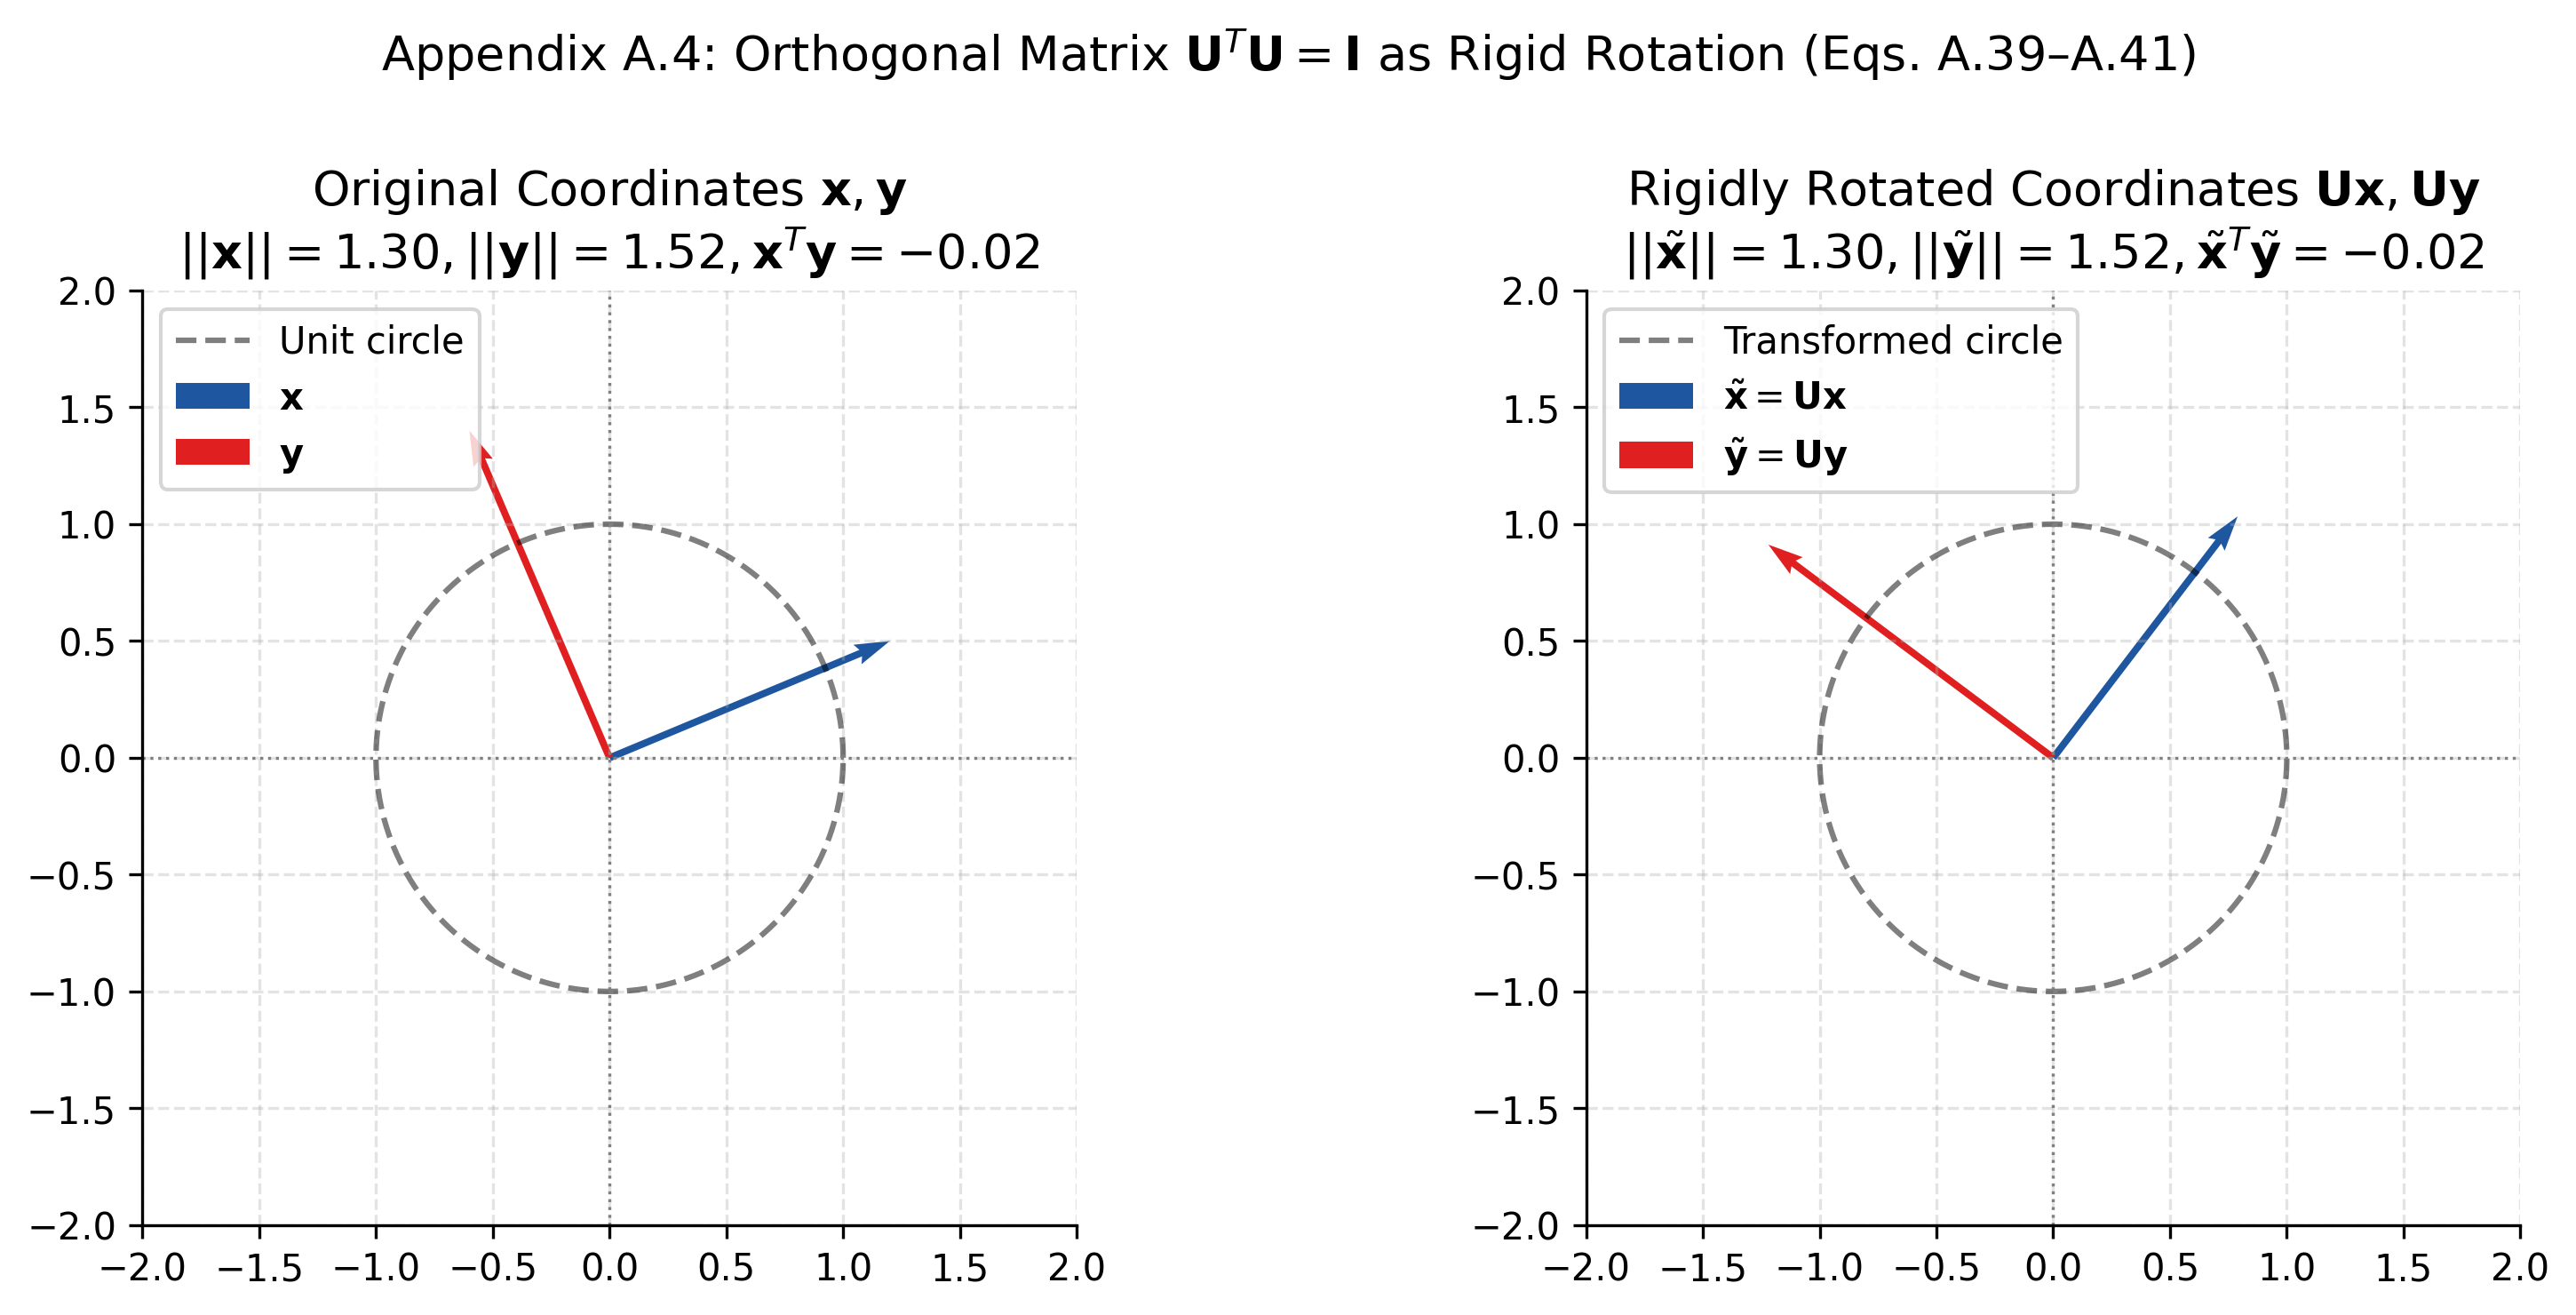

--- Figure A.2: スペクトル分解 A = U Lambda U^T による主軸伸縮と楕円変形 ---


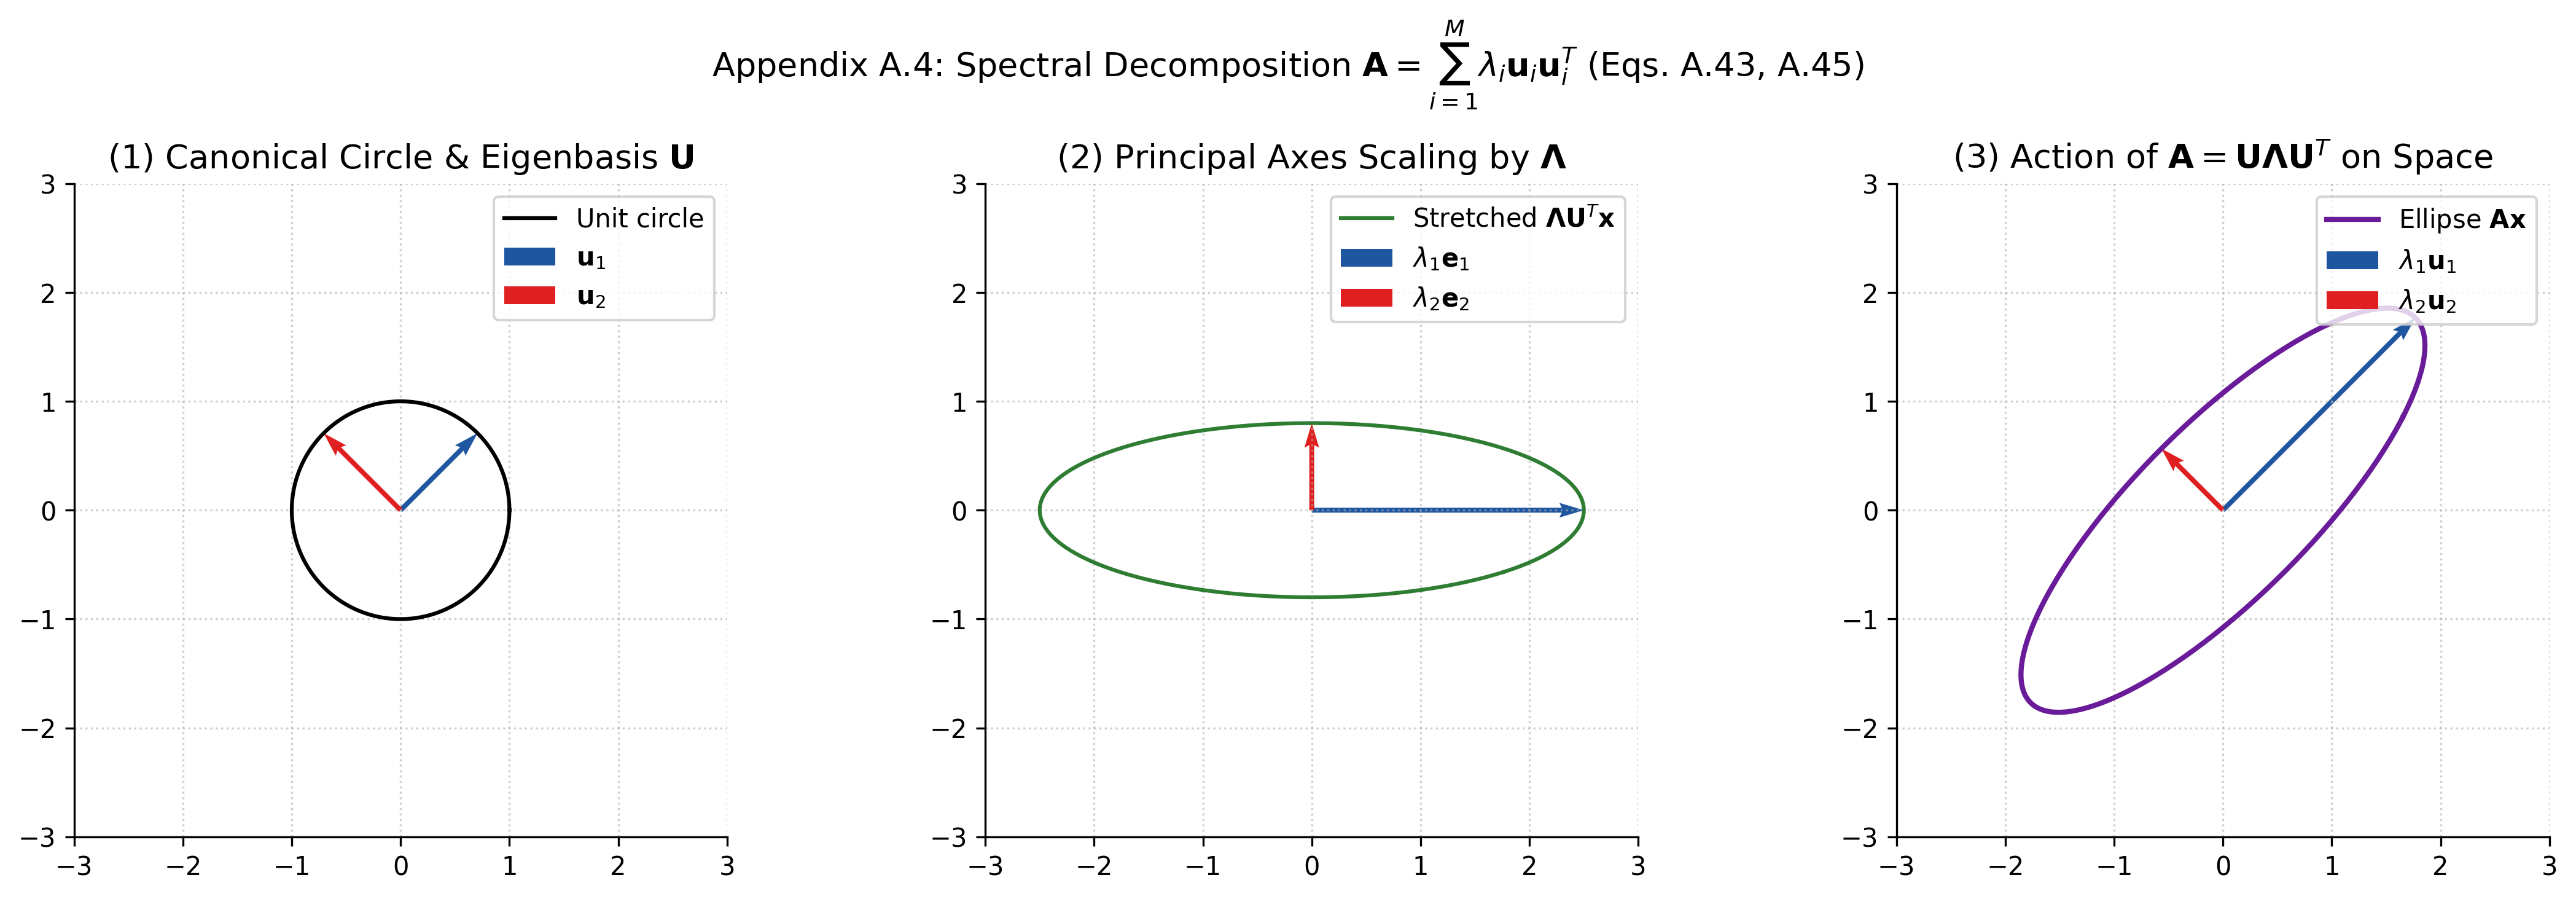

--- Figure A.3: 正定値 2次形式 vs 不定（サドル点）2次形式 (教科書式 A.49 反例) ---


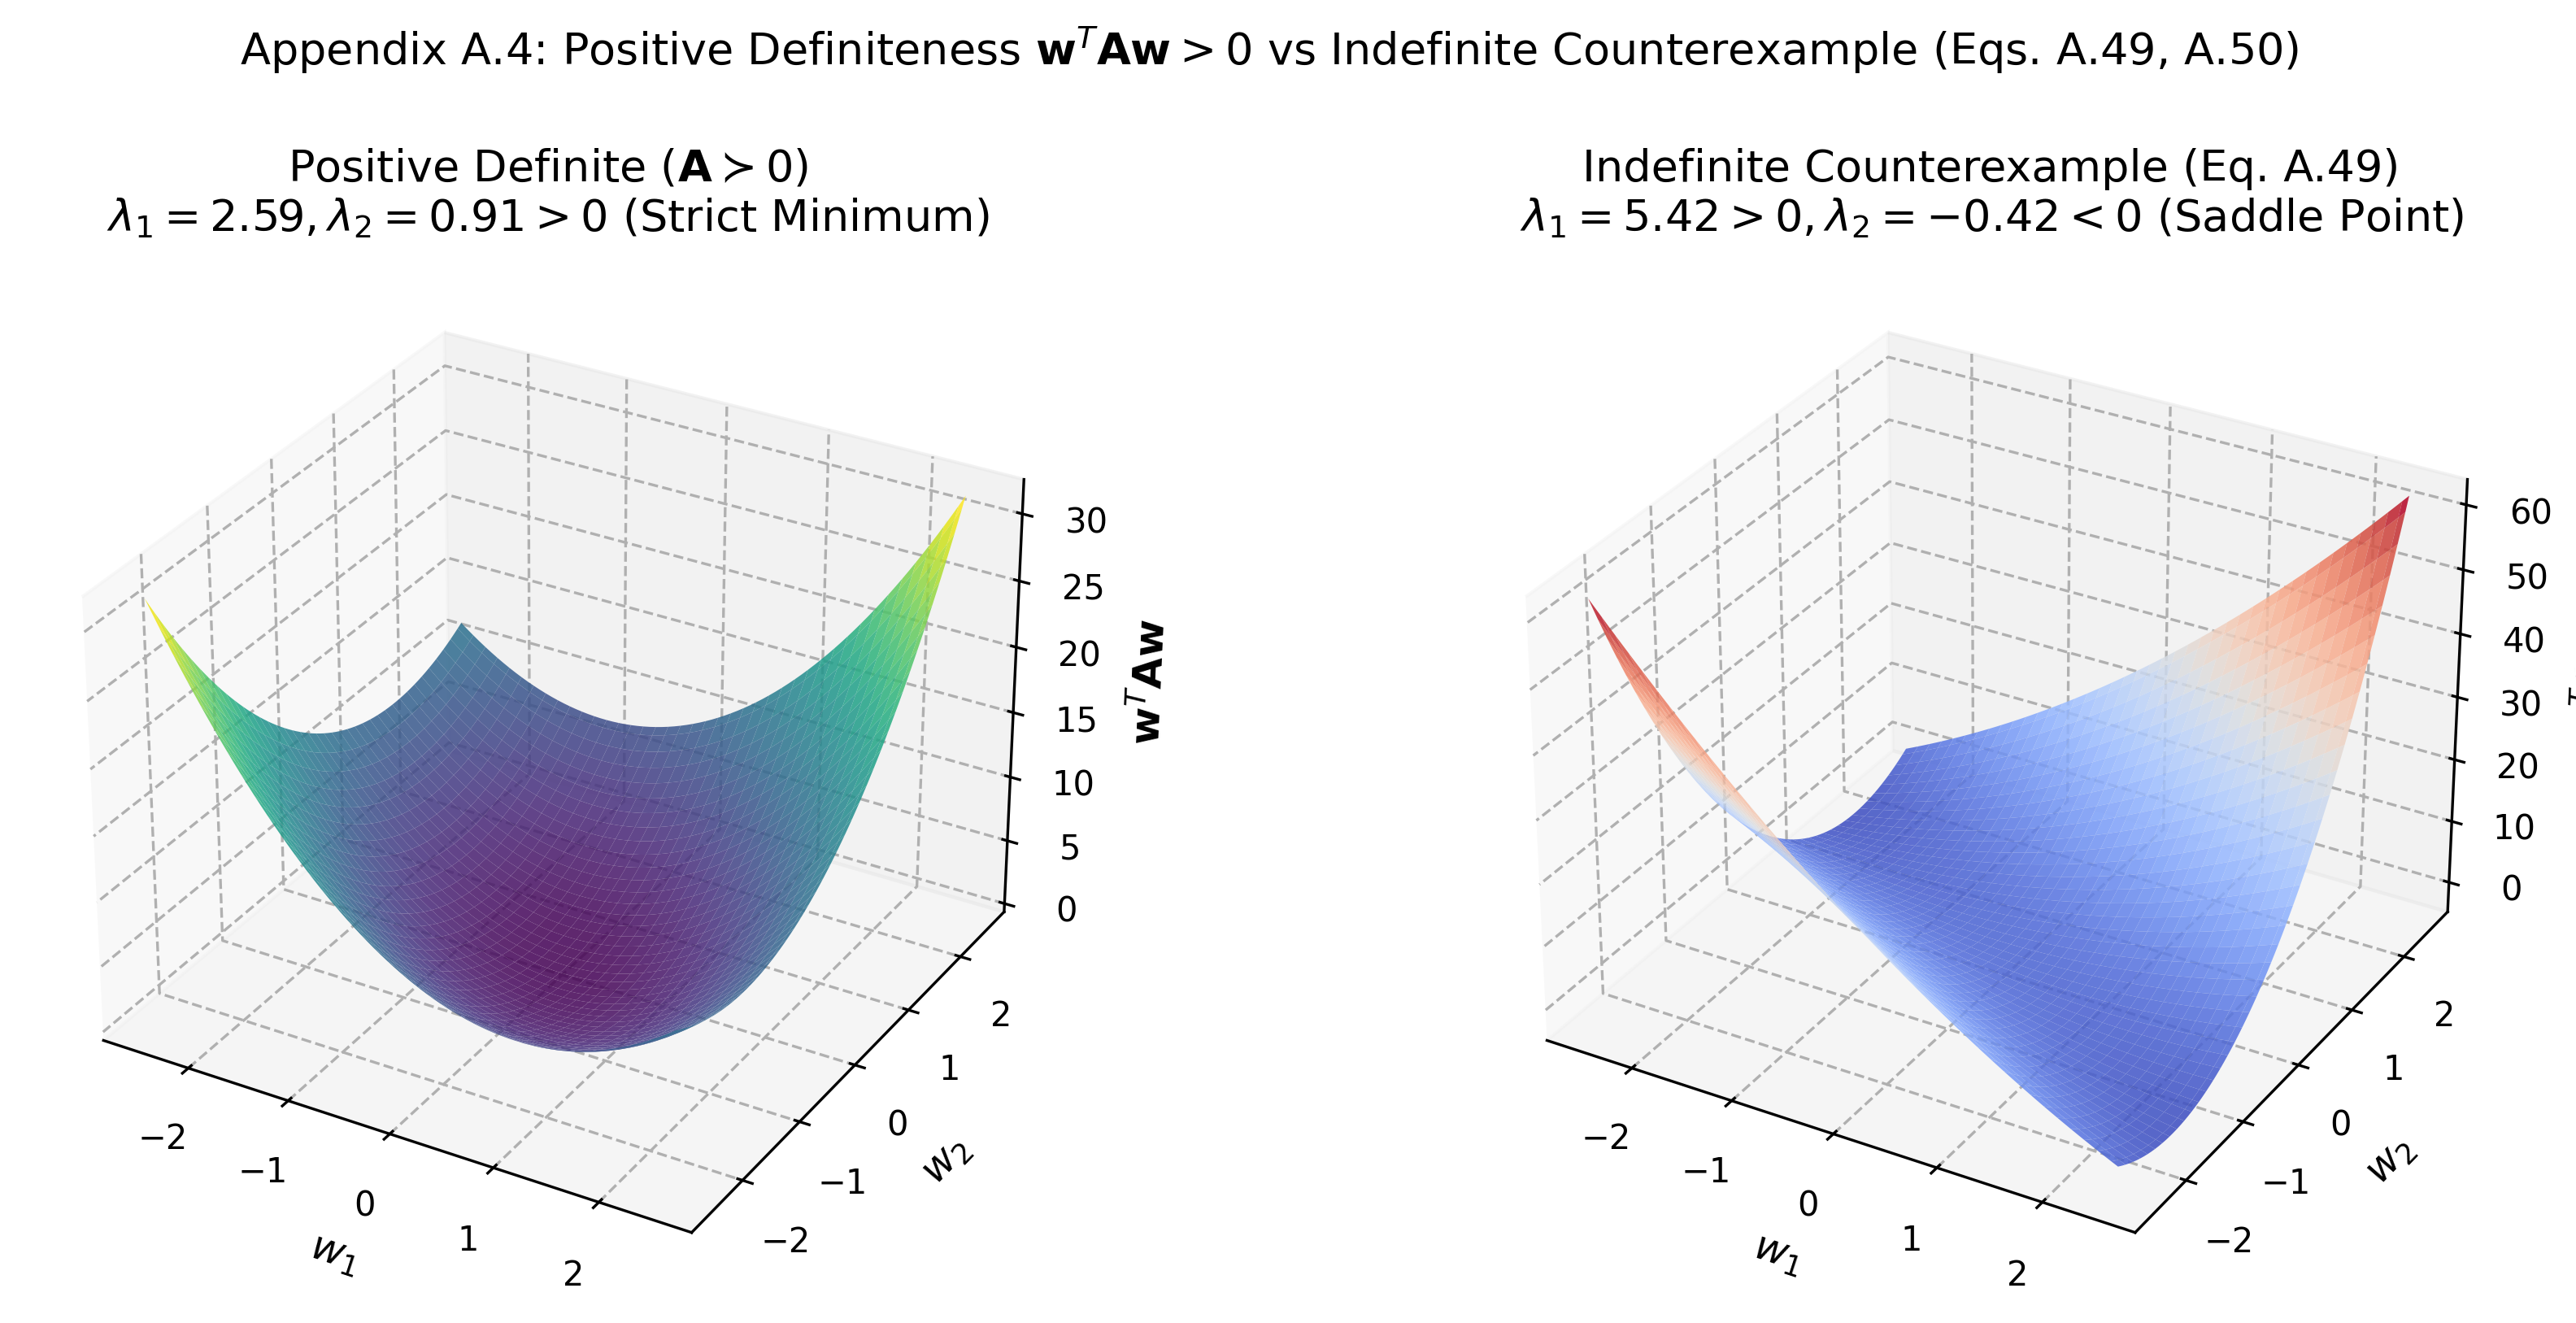

--- Figure A.4: ウッドベリー公式による計算量削減ベンチマーク (O(N^3) vs O(M^3+NM^2)) ---


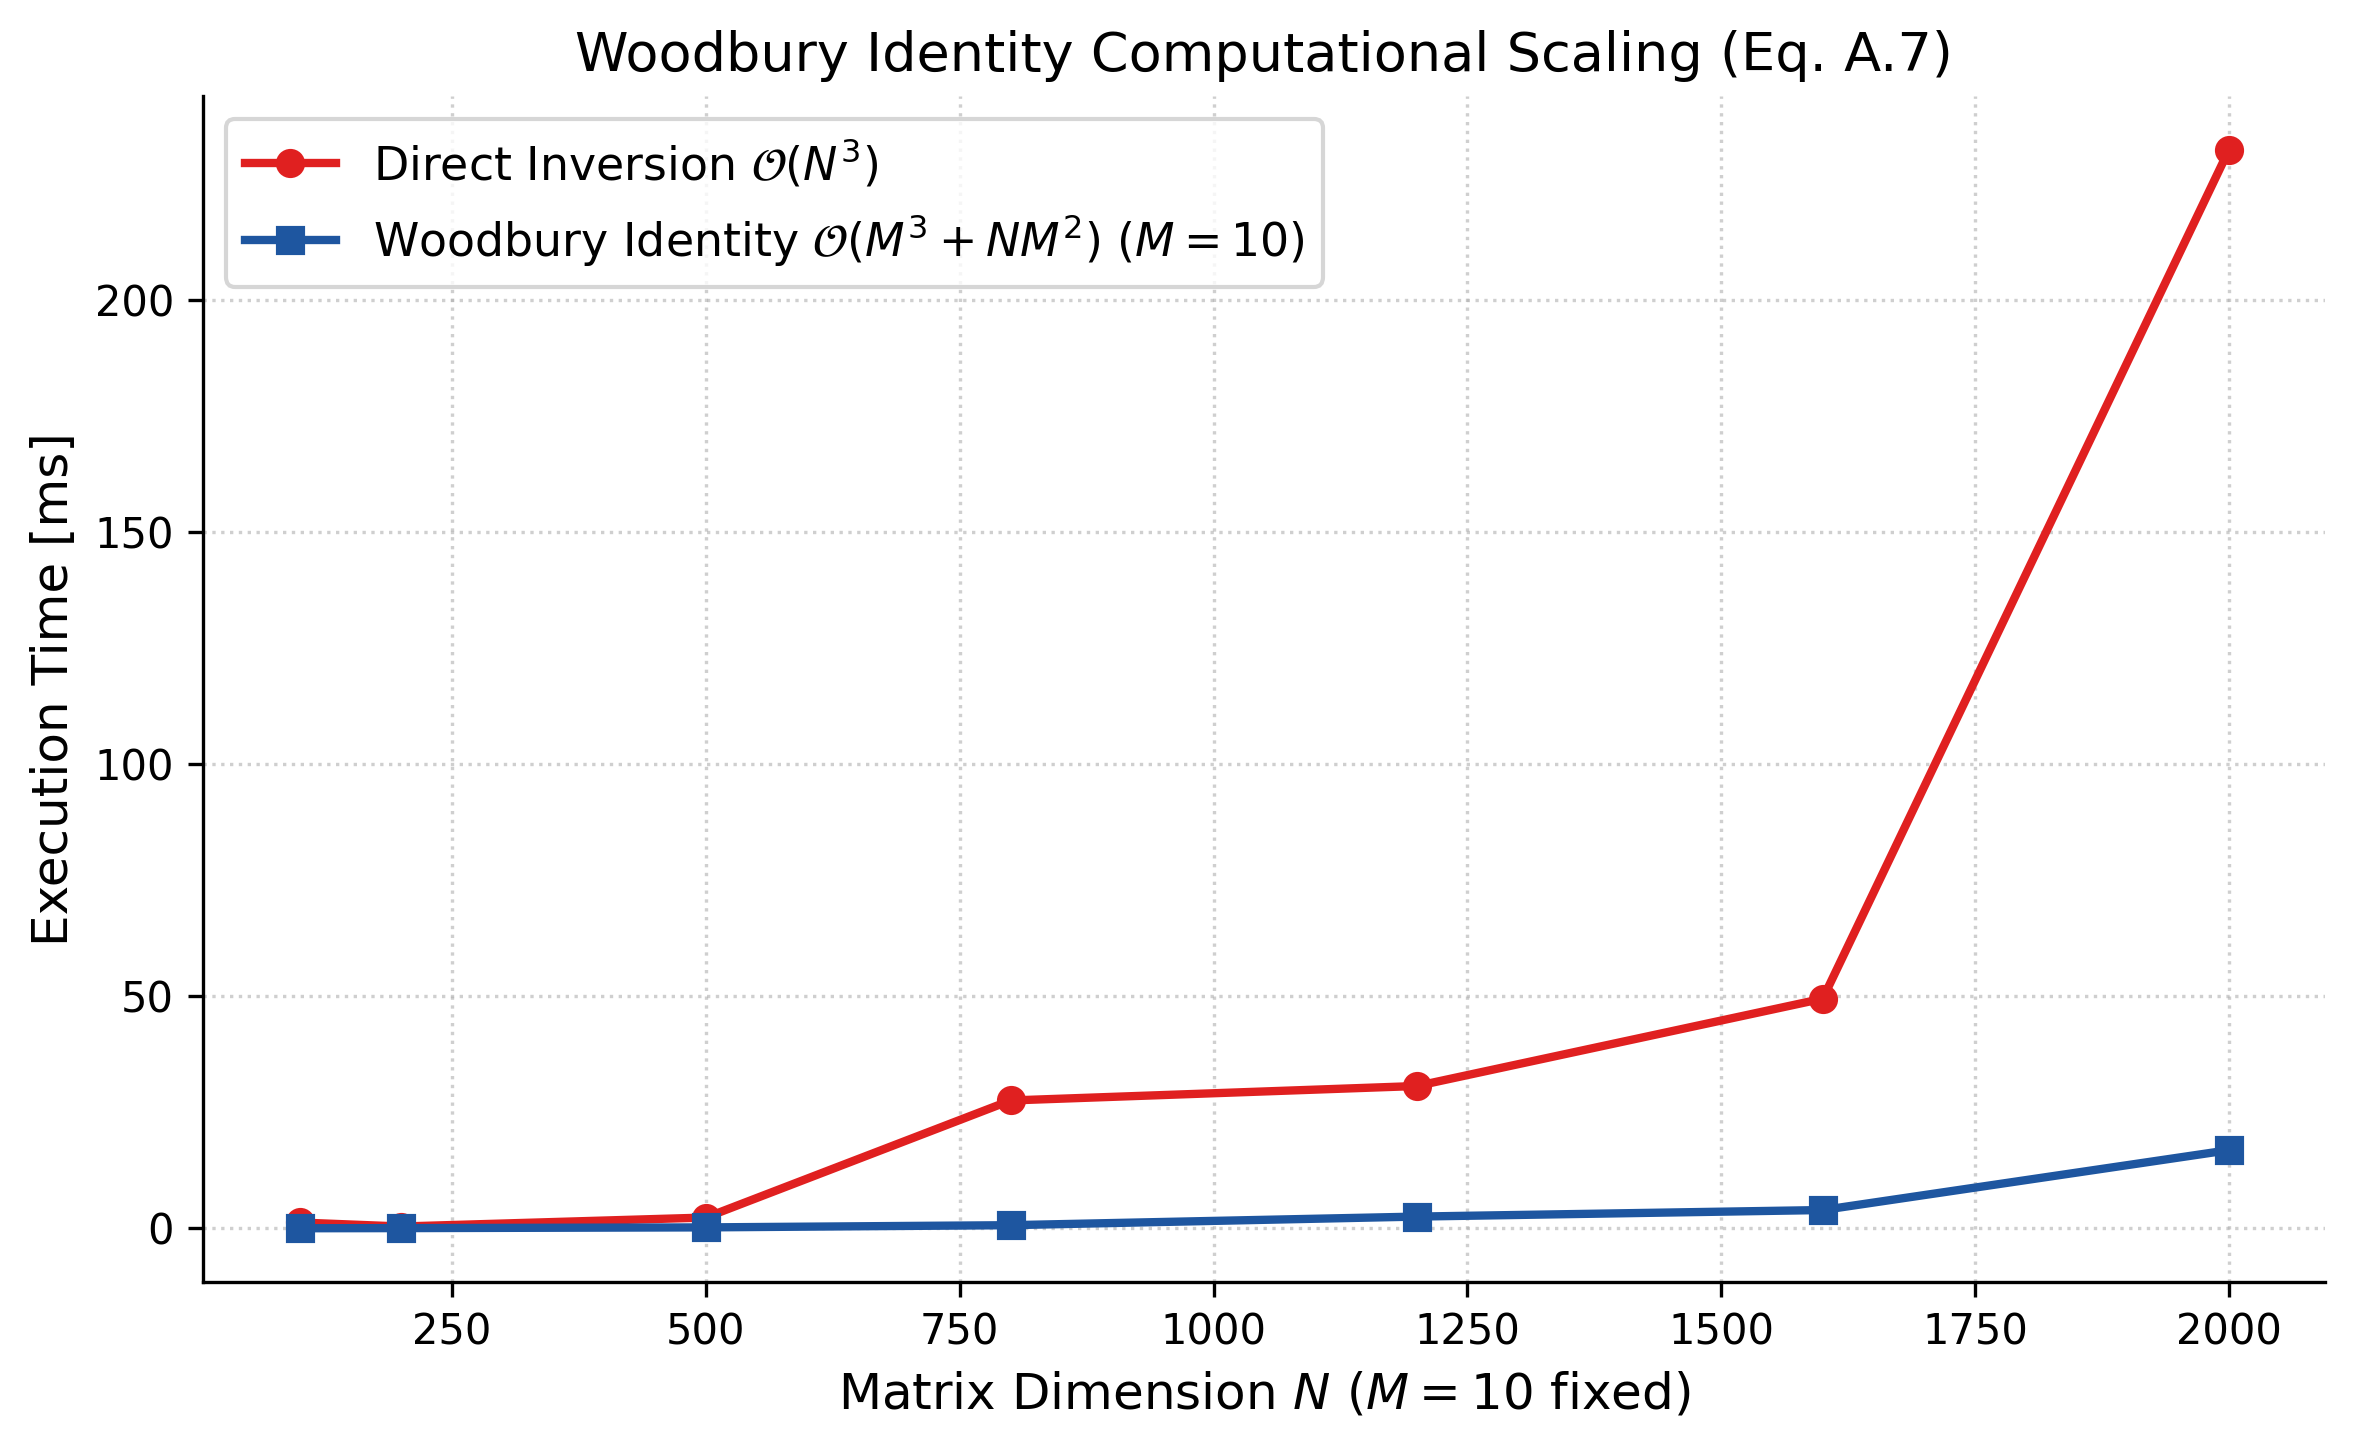

In [7]:
# === 生成された図版のインライン表示 ===
from IPython.display import Image, display

fig_dir = repo_root / "appendix" / "result"
if not (fig_dir / "figA_1_orthogonal_rotation.png").exists():
    fig_dir = Path("result")

print("--- Figure A.1: 直交行列 U による剛体回転 (ノルム・内積の不変性) ---")
display(Image(filename=str(fig_dir / "figA_1_orthogonal_rotation.png")))

print("--- Figure A.2: スペクトル分解 A = U Lambda U^T による主軸伸縮と楕円変形 ---")
display(Image(filename=str(fig_dir / "figA_2_spectral_decomposition_ellipse.png")))

print("--- Figure A.3: 正定値 2次形式 vs 不定（サドル点）2次形式 (教科書式 A.49 反例) ---")
display(Image(filename=str(fig_dir / "figA_3_quadratic_forms.png")))

print("--- Figure A.4: ウッドベリー公式による計算量削減ベンチマーク (O(N^3) vs O(M^3+NM^2)) ---")
display(Image(filename=str(fig_dir / "figA_4_woodbury_speedup.png")))


---

## まとめと深層学習への示唆

本付録では、『深層学習：基礎と概念』付録 A「線形代数」に記載されたすべての数理的恒等式（式 A.1 〜 A.50）をステップ・バイ・ステップで導出し、Python による数値検証を行いました。

### 主要な知見の総括
1. **ウッドベリーの公式 (式 A.7) と低ランク更新 (式 A.5)**:
   深層学習における疎な逆行列計算、オンライン学習、ガウス過程の高速化において決定的な役割を果たします（$M \ll N$ で $\mathcal{O}(N^3) \to \mathcal{O}(M^3 + N M^2)$）。
2. **Weinstein-Aronszajn 恒等式 (式 A.14)**:
   多変量ガウス分布の正規化定数計算や、低ランク摂動における対数行列式の高速計算に不可欠です。
3. **行列微分体系 (式 A.16 〜 A.28)**:
   トレースの微分や対数行列式の微分 $\frac{\partial}{\partial A} \ln |A| = (A^{-1})^T$ は、最尤推定や情報幾何（フィッシャー情報量行列）、VAEのELBO最適化の基礎です。
4. **実対称行列のスペクトル分解 (式 A.43 〜 A.46)**:
   任意の共分散行列やヘッセ行列は直交行列 $U$ による剛体回転と主軸方向のスケール変換 $\Lambda$ に分解でき、主成分分析（PCA）や正規化フロー、拡散モデルのスコアベース解析を数学的に支えています。
